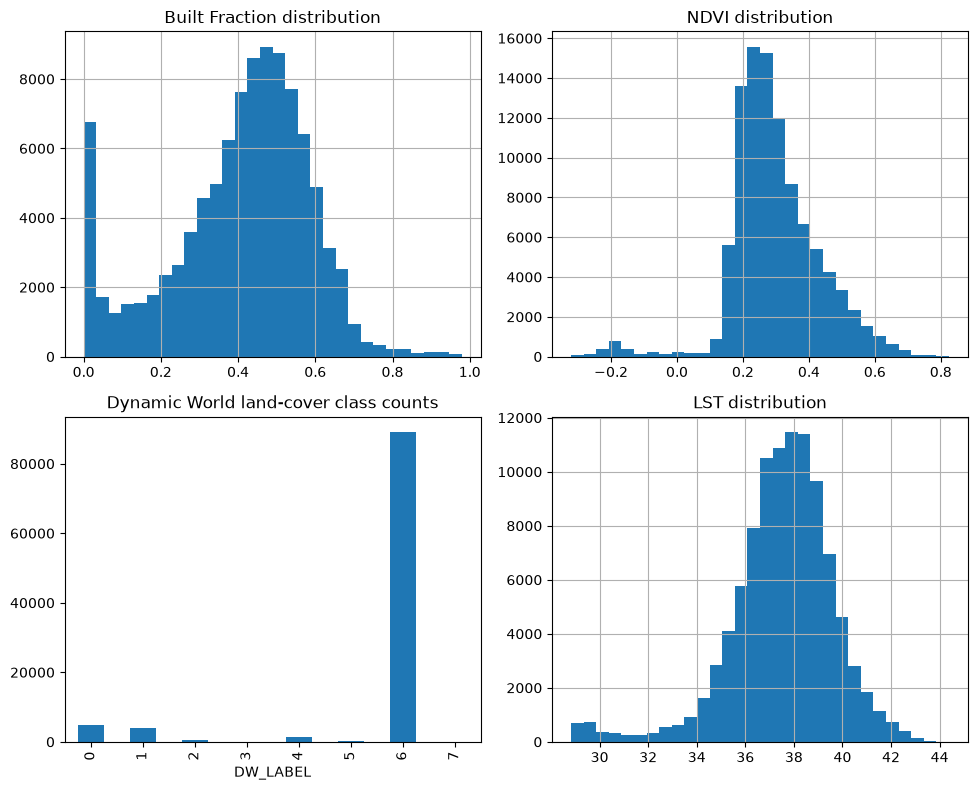

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/kolkata_training_sample.csv")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

df["BUILT_FRACTION"].hist(bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Built Fraction distribution")

df["NDVI"].hist(bins=30, ax=axes[0, 1])
axes[0, 1].set_title("NDVI distribution")

df["DW_LABEL"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Dynamic World land-cover class counts")

df["LST_C"].hist(bins=30, ax=axes[1, 1])
axes[1, 1].set_title("LST distribution")

plt.tight_layout()
plt.savefig("../outputs/sample_distribution_check.png", dpi=150)
plt.show()

In [3]:
labels = {
    0: "water", 1: "trees", 2: "grass", 3: "flooded_vegetation",
    4: "crops", 5: "shrub_scrub", 6: "built", 7: "bare", 8: "snow_ice"
}

counts = df["DW_LABEL"].value_counts().sort_index()
for label_id, count in counts.items():
    print(f"{labels.get(label_id, label_id)}: {count}")

water: 4951
trees: 3982
grass: 441
flooded_vegetation: 21
crops: 1308
shrub_scrub: 114
built: 89117
bare: 66


In [4]:
era5_cols = [
    "AIR_TEMP_C", "DEWPOINT_C", "WIND_SPEED_M_S", "PRECIPITATION_MM",
    "SURFACE_PRESSURE_HPA", "SOIL_MOISTURE_L1", "NET_SOLAR_RADIATION_W_M2",
    "NET_THERMAL_RADIATION_W_M2", "SENSIBLE_HEAT_FLUX_W_M2", "LATENT_HEAT_FLUX_W_M2",
]

for col in era5_cols:
    spread = df[col].max() - df[col].min()
    print(f"{col}: range={spread:.5f}  std={df[col].std():.5f}")

AIR_TEMP_C: range=0.02740  std=0.00888
DEWPOINT_C: range=0.14965  std=0.03733
WIND_SPEED_M_S: range=0.01914  std=0.00877
PRECIPITATION_MM: range=21.57220  std=4.87319
SURFACE_PRESSURE_HPA: range=0.28069  std=0.13082
SOIL_MOISTURE_L1: range=0.05684  std=0.02554
NET_SOLAR_RADIATION_W_M2: range=3.37535  std=1.47783
NET_THERMAL_RADIATION_W_M2: range=1.95302  std=0.62837
SENSIBLE_HEAT_FLUX_W_M2: range=10.44755  std=4.57491
LATENT_HEAT_FLUX_W_M2: range=14.18966  std=6.23548


In [5]:
print(df[['NDBI', 'LST_C']].corr())

           NDBI     LST_C
NDBI   1.000000  0.700783
LST_C  0.700783  1.000000


In [6]:
df.columns

Index(['longitude', 'latitude', 'AIR_TEMP_C', 'ALBEDO', 'BUILDING_HEIGHT_M',
       'BUILT_FRACTION', 'BUILT_NRES_FRACTION', 'CANYON_ASPECT_RATIO_HW',
       'DEWPOINT_C', 'DW_BARE_PROB', 'DW_BUILT_PROB', 'DW_CROPS_PROB',
       'DW_FLOODED_VEGETATION_PROB', 'DW_GRASS_PROB', 'DW_LABEL',
       'DW_SHRUB_SCRUB_PROB', 'DW_SNOW_ICE_PROB', 'DW_TREES_PROB',
       'DW_WATER_PROB', 'LATENT_HEAT_FLUX_W_M2', 'LST_C', 'MEAN_HEIGHT_150M',
       'MORPHOLOGY_MASS_PROXY', 'NDBI', 'NDVI', 'NET_SOLAR_RADIATION_W_M2',
       'NET_THERMAL_RADIATION_W_M2', 'PRECIPITATION_MM', 'S2_BSI', 'S2_MNDWI',
       'S2_NDBI', 'S2_NDVI', 'SENSIBLE_HEAT_FLUX_W_M2', 'SKY_VIEW_FACTOR',
       'SOIL_MOISTURE_L1', 'SURFACE_PRESSURE_HPA', 'WIND_SPEED_M_S'],
      dtype='str')